# GenFlix-AB-Test: Multi-Variant Analysis

This notebook analyzes the data from a multi-group (A/B/C/D/E) simulation. The goal is to determine if different AI-generated synopsis personas had a statistically significant impact on user click-through rates (CTR) compared to the original synopsis (control group).

**Analysis Plan:**
1.  **Descriptive Analysis:** Calculate and visualize the raw CTR for each group.
2.  **Confidence Intervals:** Estimate the uncertainty around each group's CTR.
3.  **Overall Significance (Omnibus Test):** Use a Chi-Squared test to see if there is *any* significant difference among the groups.
4.  **Pairwise Comparisons (Post-Hoc Test):** If the overall test is significant, perform pairwise tests with Bonferroni correction to identify *which specific groups* differ.

## Import necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportion_confint
from itertools import combinations
from pathlib import Path

sns.set_theme(style="whitegrid")

## Load and Inspect the Data

In [2]:
try:
    notebook_path = Path().absolute()
    BASE_DIR = notebook_path.parent
except:
    BASE_DIR = Path.cwd().parent

SIMULATION_RESULTS_PATH = BASE_DIR / "data" / "processed" / "simulation_results.csv"

try:
    df = pd.read_csv(SIMULATION_RESULTS_PATH)
    print("Data loaded successfully!")
    print(f"Dataset contains {len(df)} records.")
except FileNotFoundError:
    print(f"Error: File not found at {SIMULATION_RESULTS_PATH}")
    print("Please make sure you have run 'python src/ab_simulator.py' first.")


if 'df' in locals():
    print("\nFirst 5 rows of the dataset:")
    display(df.head())

Data loaded successfully!
Dataset contains 100000 records.

First 5 rows of the dataset:


,user_id,group,show_id,clicked
0,0,serious,s6063,0
1,1,serious,s7240,0
2,2,control,s2326,0
3,3,control,s7612,0
4,4,control,s6593,0


## Summary Table and Initial Visualization

Performance Summary by Group:


,group,impressions,clicks,ctr
0,control,20293,853,0.042034
1,enthusiastic,19968,1144,0.057292
2,mysterious,19864,1032,0.051953
3,serious,19889,847,0.042586
4,witty,19986,1072,0.053638


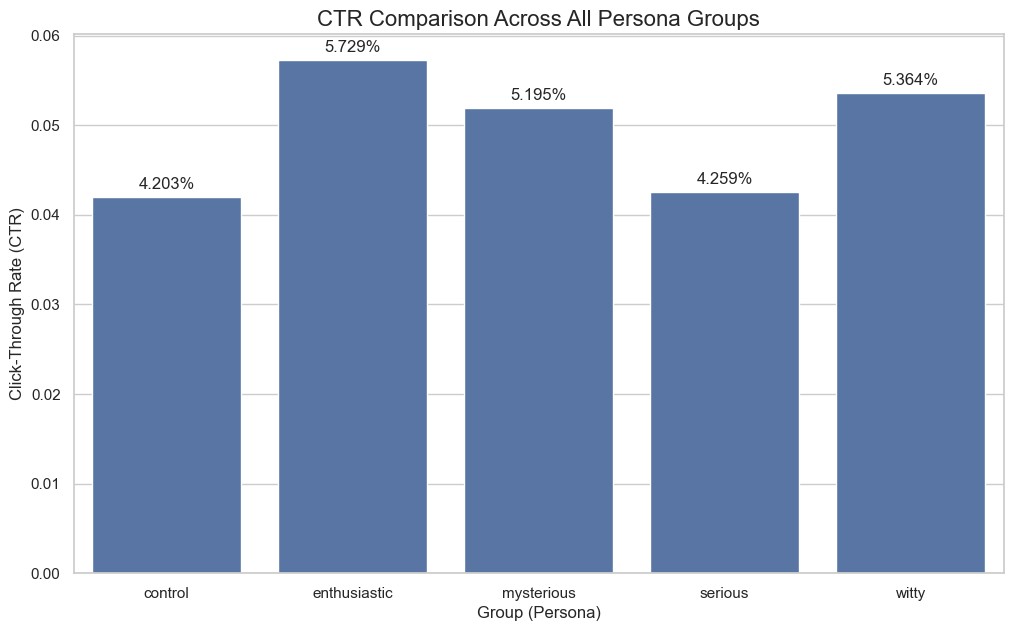

In [3]:
# Calculate performance metrics for all groups
summary_df = df.groupby('group').agg(
    impressions=('user_id', 'count'),
    clicks=('clicked', 'sum')
).reset_index()

summary_df['ctr'] = summary_df['clicks'] / summary_df['impressions']

# Order the groups for better visualization (control first)
group_order = ['control'] + sorted([g for g in summary_df['group'] if g != 'control'])
summary_df['group'] = pd.Categorical(summary_df['group'], categories=group_order, ordered=True)
summary_df = summary_df.sort_values('group')

print("Performance Summary by Group:")
display(summary_df)

# Visualize the CTRs
plt.figure(figsize=(12, 7))
ax = sns.barplot(x='group', y='ctr', data=summary_df, order=group_order)
ax.set_title('CTR Comparison Across All Persona Groups', fontsize=16)
ax.set_xlabel('Group (Persona)', fontsize=12)
ax.set_ylabel('Click-Through Rate (CTR)', fontsize=12)

# Add percentage labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3%}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points')
plt.show()

## Visualizing Confidence Intervals

The bar chart shows point estimates of the CTRs, but it doesn't show the uncertainty in these estimates. A better way to visualize the results is to plot the CTRs with their 95% confidence intervals. If the intervals for two groups do not overlap, it's a strong visual indicator of a statistically significant difference.

Summary with 95% Confidence Intervals:


,group,ctr,ci_lower,ci_upper
0,control,0.042034,0.039273,0.044795
1,enthusiastic,0.057292,0.054068,0.060515
2,mysterious,0.051953,0.048867,0.055040
3,serious,0.042586,0.039780,0.045393
4,witty,0.053638,0.050514,0.056761


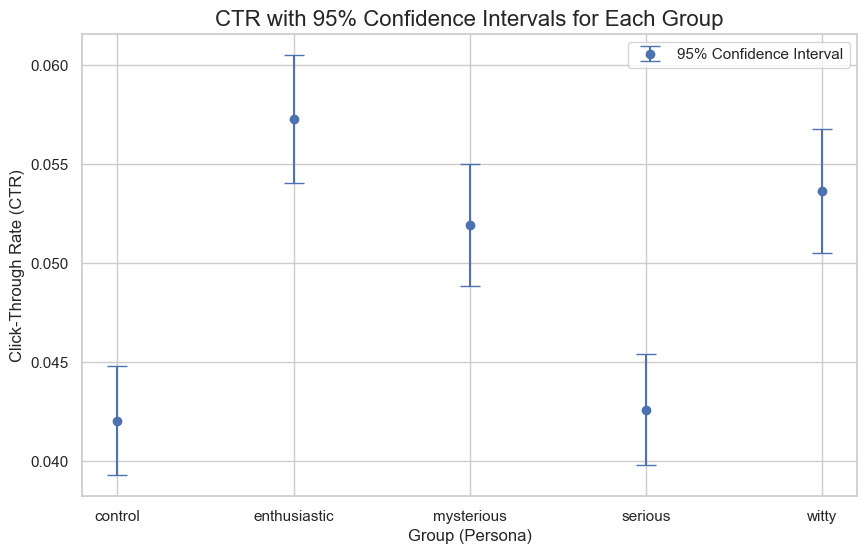

In [4]:
summary_df['ci_lower'], summary_df['ci_upper'] = proportion_confint(
    count=summary_df['clicks'], 
    nobs=summary_df['impressions'], 
    alpha=0.05, 
    method='normal'
)

# Calculate the error margin for the plot
summary_df['error'] = summary_df['ci_upper'] - summary_df['ctr']

print("Summary with 95% Confidence Intervals:")
display(summary_df[['group', 'ctr', 'ci_lower', 'ci_upper']])

# Plotting the CTRs with error bars representing the confidence intervals
plt.figure(figsize=(10, 6))
plt.errorbar(x=summary_df['group'], 
             y=summary_df['ctr'], 
             yerr=summary_df['error'], 
             fmt='o',
             linestyle='', 
             capsize=7,
             label='95% Confidence Interval')

plt.title('CTR with 95% Confidence Intervals for Each Group', fontsize=16)
plt.xlabel('Group (Persona)', fontsize=12)
plt.ylabel('Click-Through Rate (CTR)', fontsize=12)
plt.grid(True, axis='y')
plt.legend()
plt.show()

## Stage 1: Overall Significance Test (Omnibus Chi-Squared)

We first test the null hypothesis that there is no association between any of the groups and the click-through rate. A low p-value (typically < 0.05) will indicate that at least one group's performance is significantly different from the others.

In [5]:
# Create a contingency table for all groups
contingency_table_overall = pd.crosstab(df['group'], df['clicked'])
print("Overall Contingency Table:")
display(contingency_table_overall)

# Perform the Chi-Squared test
chi2, p_value, dof, expected = chi2_contingency(contingency_table_overall)

print(f"\n--- Omnibus Test Results ---")
print(f"Chi-Squared Statistic: {chi2:.4f}")
print(f"P-value: {p_value}")

alpha = 0.05
is_significant = p_value < alpha

if is_significant:
    print(f"\nConclusion: The result is statistically significant (p < {alpha}).")
    print("There is a significant difference among the groups. Proceeding to Post-Hoc analysis.")
else:
    print(f"\nConclusion: The result is not statistically significant (p >= {alpha}).")
    print("There is no evidence of a significant difference among the groups. Analysis stops here.")

Overall Contingency Table:


clicked,0,1
group,,
control,19440,853
enthusiastic,18824,1144
mysterious,18832,1032
serious,19042,847
witty,18914,1072



--- Omnibus Test Results ---
Chi-Squared Statistic: 79.8541
P-value: 1.8702879244093996e-16

Conclusion: The result is statistically significant (p < 0.05).
There is a significant difference among the groups. Proceeding to Post-Hoc analysis.


## Stage 2: Post-Hoc Analysis with Bonferroni Correction

Since the overall result was significant, we now perform pairwise comparisons to see which specific groups differ. We will compare each persona against the control group, as this is our primary interest.

To avoid inflating our Type I error rate (false positives) from conducting multiple tests, we apply the **Bonferroni correction**. This is done by dividing our initial significance level (alpha) by the number of comparisons we make.

In [6]:
if is_significant:
    # Define the pairs we want to compare: each persona vs. control
    all_groups = summary_df['group'].tolist()
    pairs_to_compare = [('control', group) for group in all_groups if group != 'control']
    num_comparisons = len(pairs_to_compare)
    corrected_alpha = alpha / num_comparisons

    print(f"--- Post-Hoc Pairwise Comparisons ---")
    print(f"Original Alpha: {alpha}")
    print(f"Number of Comparisons: {num_comparisons}")
    print(f"Bonferroni Corrected Alpha: {corrected_alpha}\n")

    post_hoc_results = []

    for group1, group2 in pairs_to_compare:
        # Filter data for the two groups being compared
        pair_df = df[df['group'].isin([group1, group2])]
        
        # Create a 2x2 contingency table for the pair
        contingency_table_pair = pd.crosstab(pair_df['group'], pair_df['clicked'])
        
        # Perform Chi-Squared test for the pair
        chi2_pair, p_value_pair, _, _ = chi2_contingency(contingency_table_pair)
        
        # Check for significance against the corrected alpha
        significant_pair = p_value_pair < corrected_alpha
        
        post_hoc_results.append({
            'Comparison': f"{group1} vs. {group2}",
            'P-value': f"{p_value_pair}",
            'Significant?': 'Yes' if significant_pair else 'No'
        })

    # Display results in a clean DataFrame
    results_table = pd.DataFrame(post_hoc_results)
    display(results_table)
else:
    print("Skipping Post-Hoc analysis as the overall test was not significant.")

--- Post-Hoc Pairwise Comparisons ---
Original Alpha: 0.05
Number of Comparisons: 4
Bonferroni Corrected Alpha: 0.0125



,Comparison,P-value,Significant?
0,control vs. enthusiastic,2.1115381562900892e-12,Yes
1,control vs. mysterious,2.9403985159497955e-06,Yes
2,control vs. serious,0.8024842244370007,No
3,control vs. witty,5.488918880775095e-08,Yes


## Stage 3: Comparing the Winning Personas

We've established that the 'enthusiastic', 'mysterious', and 'witty' personas are all significantly better than the control group. The final question is: is there a statistically significant difference *among these winning personas*?

This helps us determine if there is a single "best" persona or if they perform similarly. We will again use pairwise Chi-Squared tests with a Bonferroni correction for this new set of comparisons.

In [7]:
# This cell should only be run if the initial omnibus test was significant
if is_significant:
    # Identify the winning personas from the previous analysis
    winners_table = results_table[results_table['Significant?'] == 'Yes']
    # Extract the persona names from the 'Comparison' column
    winning_personas = [comp.split(' vs. ')[1] for comp in winners_table['Comparison']]
    
    print(f"The winning personas to be compared are: {winning_personas}")

    # Create all possible pairs of winners
    if len(winning_personas) > 1:
        pairs_to_compare_winners = list(combinations(winning_personas, 2))
        
        num_winner_comparisons = len(pairs_to_compare_winners)
        corrected_alpha_winners = alpha / num_winner_comparisons

        print(f"\n--- Winner-vs-Winner Pairwise Comparisons ---")
        print(f"Number of new comparisons: {num_winner_comparisons}")
        print(f"Bonferroni Corrected Alpha for this stage: {corrected_alpha_winners}\n")

        winner_results = []

        for group1, group2 in pairs_to_compare_winners:
            pair_df = df[df['group'].isin([group1, group2])]
            contingency_table_pair = pd.crosstab(pair_df['group'], pair_df['clicked'])
            
            chi2_pair, p_value_pair, _, _ = chi2_contingency(contingency_table_pair)
            
            significant_pair = p_value_pair < corrected_alpha_winners
            
            winner_results.append({
                'Comparison': f"{group1} vs. {group2}",
                'P-value': f"{p_value_pair:.4f}",
                'Significant?': 'Yes' if significant_pair else 'No'
            })

        # Display the results of the winner comparisons
        winner_results_table = pd.DataFrame(winner_results)
        display(winner_results_table)
    else:
        print("Only one winning persona found, no further comparison needed.")
else:
    print("Skipping this stage as the initial test was not significant.")

The winning personas to be compared are: ['enthusiastic', 'mysterious', 'witty']

--- Winner-vs-Winner Pairwise Comparisons ---
Number of new comparisons: 3
Bonferroni Corrected Alpha for this stage: 0.016666666666666666



,Comparison,P-value,Significant?
0,enthusiastic vs. mysterious,0.0202,No
1,enthusiastic vs. witty,0.1156,No
2,mysterious vs. witty,0.4658,No


## Final Conclusion and Business Recommendation

The analysis reveals a clear and actionable outcome. The initial omnibus test confirmed a significant difference among the groups, and the first round of post-hoc tests successfully identified three "winning" personas—'enthusiastic', 'mysterious', and 'witty'—that all significantly outperform the original synopsis.

The final and most crucial stage was to determine if a single best persona exists among these winners.

### Interpretation of Winner-vs-Winner Results

The results of the final pairwise comparison are conclusive:

**There is no statistically significant difference in performance among the 'enthusiastic', 'mysterious', and 'witty' personas.**

As shown in the table, the p-values for all three comparisons are greater than our strict, Bonferroni-corrected significance level of **α ≈ 0.0167**. Notably, while the 'enthusiastic' persona performed slightly better than 'mysterious' (p ≈ 0.0202), this difference is not strong enough to rule out the possibility of it being due to random chance under our corrected threshold.

### Actionable Recommendation

This is a powerful finding. It means the organization is not bound to a single "best" option based on Click-Through Rate alone. The choice among the top-performing personas can now be guided by strategic business considerations rather than pure statistical optimization.

The final recommendation is to select a persona based on the following strategic factors:

1.  **Brand Alignment (Primary Factor):** Which persona best reflects the brand's voice?
    *   **'witty'**: Ideal for a modern, social-media-savvy brand that values a direct and humorous connection with its audience.
    *   **'enthusiastic'**: Perfect for a brand that wants to project energy, excitement, and a focus on blockbuster entertainment.
    *   **'mysterious'**: A more niche choice, excellent for a brand that positions itself as edgy, intellectual, or focused on the thriller/horror genres.

2.  **Contextual Application:** Instead of a single site-wide winner, consider a context-aware strategy. The **'mysterious'** persona could be deployed programmatically for the Thriller and Horror genres, while **'witty'** could be the default for Comedies and Dramas.

3.  **Simplicity and Consistency:** If the goal is to choose a single, consistent voice across the platform, any of the three winners would be a statistically valid choice. In this scenario, the **'enthusiastic'** persona, having the highest absolute CTR in our simulation, could be chosen, with the clear understanding that its lead over the others is not statistically significant.